In [ ]:
!pip install qiskit qiskit-aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy,Kraus
import numpy as np


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy,Kraus
import numpy as np

# -----------------------------
# PARAMETERS
# -----------------------------

N_BH = 8     # black hole qubits
N_ENV = 3      # environment qubits (finite bath)
SCRAMBLE_DEPTH = 5

TOTAL_QUBITS = N_BH + N_ENV


# -----------------------------
# SCRAMBLING (chaotic dynamics)
# -----------------------------

def scramble_black_hole(qc, bh):
    """
    Chaotic fast-scrambling unitary.
    Mimics Haar random circuit using layered local + global entanglement.
    Increased complexity for more chaotic behavior by incorporating diverse
    gate types and entanglement patterns.
    """

    LAYERS = 20 # Increased layers for more chaotic behavior

    for _ in range(LAYERS):

        # --- random single-qubit rotations (local chaos) ---
        # Using rx, ry, rz for diverse random single-qubit operations
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)

        # --- diverse nearest-neighbour entanglement (local spreading) ---
        if len(bh) > 1:
            for i in range(len(bh)-1):
                qc.cx(bh[i], bh[i+1]) # Original CNOT
                qc.cz(bh[i], bh[i+1]) # Added CZ for more diversity
                qc.cy(bh[i+1], bh[i]) # Added CY with swapped control/target for diversity

        # --- diverse long-range entanglement (global scrambling) ---
        if len(bh) > 1: # Ensure there are at least 2 qubits for long-range interactions
            # Original long-range CZ pattern
            for i in range(len(bh)//2):
                qc.cz(bh[i], bh[-(i+1)])

            # Additional long-range connections
            if len(bh) > 3: # Need at least 4 qubits for these specific connections
                qc.cx(bh[0], bh[-1]) # CNOT between first and last qubit
                qc.cy(bh[1], bh[-2]) # CY between second and second-to-last
                qc.cz(bh[0], bh[-2]) # CZ between first and second-to-last

        # --- random SWAP layer (operator growth) ---
        # This helps in quickly spreading entanglement
        for i in range(0, len(bh)-1, 2):
            qc.swap(bh[i], bh[i+1])



def markovian_decohere(rho, qubit, gamma=0.25):
    """
    Apply phase damping channel (memoryless bath).
    Destroys quantum correlations irreversibly.
    """

    K0 = np.array([[1, 0],
                   [0, np.sqrt(1-gamma)]])

    K1 = np.array([[0, 0],
                    [0, np.sqrt(gamma)]])

    channel = Kraus([K0, K1])

    return rho.evolve(channel, [qubit])


# -----------------------------
# ENVIRONMENT DYNAMICS
# -----------------------------

def evolve_environment(qc, env):
    """
    Environment self-interaction (stores memory).
    Introduced more diverse and random operations for environment evolution.
    """
    if len(env) < 2:
        return

    for i in range(len(env)-1):
        qc.cx(env[i], env[i+1])
        qc.cz(env[i+1], env[i]) # Added CZ with reversed control and targets for more environmental entanglement
        qc.rx(np.random.uniform(0, 2*np.pi), env[i]) # Random angles
        qc.ry(np.random.uniform(0, 2*np.pi), env[i+1]) # Random angles
        qc.rz(np.random.uniform(0, 2*np.pi), env[i]) # Added RZ for more diversity


# -----------------------------
# BH-ENV COUPLING
# -----------------------------

def bh_environment_interaction(qc, bh, env):
    """Information exchange between system and bath"""
    for b in bh:
        for e in env:
            qc.cz(b, e)
            qc.rx(np.pi/8, b)
            qc.ry(np.pi/8, e)

#---------------- Markovian evaporation-----------
def run_markovian_evaporation():

    # start with pure BH state only
    rho_B = DensityMatrix.from_label('0' * N_BH)

    bh_size = N_BH

    entropies = []
    steps = []
    complexity = []

    step = 0

    while bh_size > 0:

        step += 1

        # --- create a fresh vacuum radiation qubit ---
        rho_rad = DensityMatrix.from_label('0')

        # combine BH + outgoing qubit
        rho_total = rho_B.tensor(rho_rad)

        # build circuit acting on BH + emitted qubit
        qc = QuantumCircuit(bh_size + 1)

        bh_qubits = list(range(bh_size))
        emitted = bh_size

        # scrambling inside BH
        scramble_black_hole(qc, bh_qubits)

        # Hawking pair creation (entangle with outgoing qubit)
        qc.cx(bh_qubits[0], emitted)
        qc.ry(np.pi/4, emitted)

        # evolve density matrix
        rho_total = rho_total.evolve(qc)

        # -------- TRUE MARKOVIAN STEP --------
        # radiation escapes to infinity
        rho_B = partial_trace(rho_total, [emitted])

        bh_size -= 1

        # radiation entropy = lost information
        S_R = entropy(rho_R, base=2)
        entropies.append(S_R)
        complexity.append(len(qc.data))
        steps.append(step)

        print(f"[True Markovian] Step {step} | S(R) ≈ {S_R:.4f}")

    return steps, entropies,complexity



# -----------------------------
# NON-MARKOVIAN EVAPORATION
# -----------------------------

def run_evaporation():

    qc = QuantumCircuit(TOTAL_QUBITS)
    state = Statevector.from_instruction(qc)

    bh = list(range(N_BH))
    env = list(range(N_BH, TOTAL_QUBITS))
    radiation = []

    entropies = []
    steps = []
    complexity = []

    step = 0

    while len(bh) > 0:

        step += 1

        # 1. BH scrambling
        scramble_black_hole(qc, bh)

        # 2. environment evolves
        evolve_environment(qc, env)

        # 3. BH <-> environment interaction
        bh_environment_interaction(qc, bh, env)

        # update global state
        state = Statevector.from_instruction(qc)

        # 4. emission
        emitted = bh.pop(0)
        radiation.append(emitted)

        # 5. compute radiation entropy
        trace_out = bh + env
        rho_R = partial_trace(state, trace_out)
        S_R = entropy(rho_R, base=2)

        entropies.append(S_R)

        complexity.append(len(qc.data))
        steps.append(step)

        print(f"[Non-Markovian] Step {step} | S(R) = {S_R:.4f}")

    return steps, entropies, complexity


# -----------------------------
# MAIN
# -----------------------------

if __name__ == "__main__":

    # Run Markovian evaporation first
    steps_m_comp, S_m_comp, C_m = run_markovian_evaporation()

    # Then run Non-Markovian evaporation
    steps_nm_comp, S_nm_comp, C_nm = run_evaporation()

    # Calculate entropy production rates
    dS_m_comp = np.diff(S_m_comp)
    dS_nm_comp = np.diff(S_nm_comp)

    # Plot Radiation Entropy Comparison
    plt.figure(figsize=(10,6))
    plt.plot(steps_m_comp, S_m_comp, 's--', label="Markovian (memoryless bath)")
    plt.plot(steps_nm_comp, S_nm_comp, 'o-', label="Non-Markovian (finite bath)")
    plt.xlabel("Emission step")
    plt.ylabel("Radiation entropy S(R)")
    plt.title("Comparison: Markovian vs Non-Markovian Black Hole Evaporation (Radiation Entropy)")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot Entropy Production Rate Comparison
    plt.figure(figsize=(10,6))
    plt.plot(steps_m_comp[1:], dS_m_comp, 's--', label="Markovian dS/dt")
    plt.plot(steps_nm_comp[1:], dS_nm_comp, 'o-', label="Non-Markovian dS/dt")
    plt.axhline(0, linestyle='--', color='gray')
    plt.xlabel("Emission step")
    plt.ylabel("dS/dt")
    plt.title("Comparison: Markovian vs Non-Markovian Black Hole Evaporation (Entropy Production Rate)")
    plt.legend()
    plt.grid()
    plt.show()

NameError: name 'rho_R' is not defined

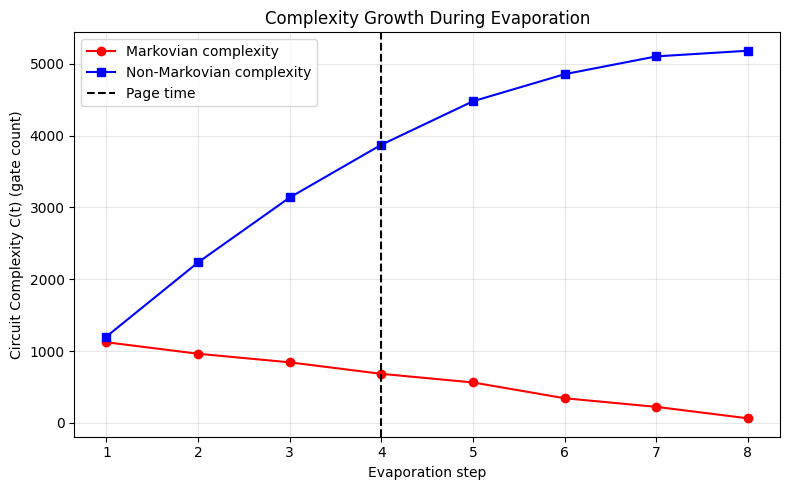

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(steps_m_comp, C_m, 'r-o', label="Markovian complexity")
plt.plot(steps_nm_comp, C_nm, 'b-s', label="Non-Markovian complexity")

plt.axvline(len(steps_nm_comp)//2, linestyle='--', color='black', label="Page time")

plt.xlabel("Evaporation step")
plt.ylabel("Circuit Complexity C(t) (gate count)")
plt.title("Complexity Growth During Evaporation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


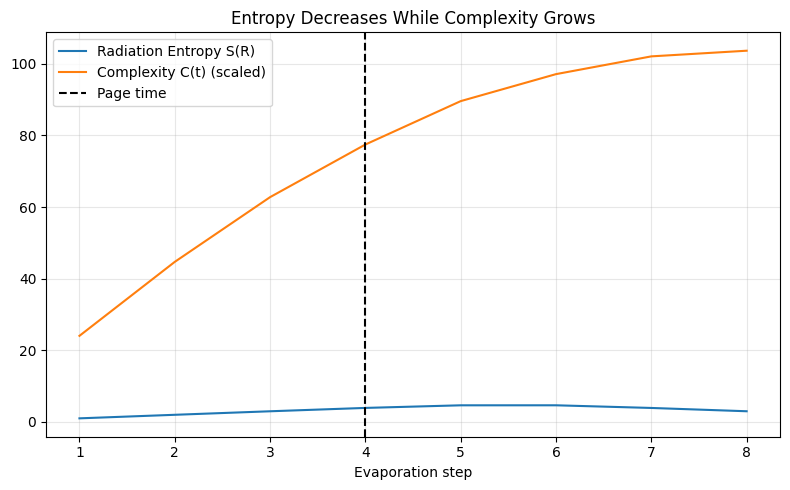

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(steps_nm_comp, S_nm_comp, label="Radiation Entropy S(R)")
plt.plot(steps_nm_comp, [i/50 for i in C_nm], label="Complexity C(t) (scaled)")

plt.axvline(len(steps_nm_comp)//2, linestyle='--', color='black', label="Page time")

plt.xlabel("Evaporation step")
plt.title("Entropy Decreases While Complexity Grows")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
